# Project data exploration - looking at relplot and scatter plots
Using a dataset that your group is consider using for the term project, let's do some data exploring of the different features in your dataset and their relationships

Group name: Dyamic  
Created by Scott Du (016955484), Sanjitha Kurra (), Dalen Martin ()  
Last updated: March 9, 2026  

The dataset is derived from the Canadian Institute for Cybersecurity. The dataset has 225,745 entries. The dataset also includes 85 columns recording important information about the traffic such as the timestamp, IPs, statistics about forward and backward packets and their time statistics, and which protocol was used. Some columns could be ignored because all entries have the same value, but were kept in for simplicity and in case any important information is lost during training of the models. Other important information within the dataset are data like act_data_pkt_fwd, which is a feature that represents the number of packets that has a TCP payload and is used specifically used for detection of malicious traffic.  

In the codes below, the dataset was split between benign and malicious traffic or filtered to include and convey the necessary details on the plots.

Import your data. If you want to mount your Google drive you can use `from google.colab import drive` and `drive.mount('/content/drive')`

In [66]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

ddos = pd.read_csv("/content/drive/Shareddrives/CS133 Project/dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
ddos.columns = ddos.columns.str.strip()
ddos.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [68]:
benign = ddos[ddos['Label'] == 'BENIGN']
malicious = ddos[ddos['Label'] != 'BENIGN']

# benign.head()
# malicious.head()

### Q1: Show the number of missing data in each column of the dataframe

In [69]:
# Shows the columns that have missing data and how many rows of missing data.
null_counts = ddos.isnull().sum()
null_counts.rename('Null Counts', inplace=True)
null_counts[null_counts > 0]

# # Shows the counts of each column.
# with pd.option_context('display.max_rows', None):
#   print(null_counts)

# # Shows the entries with null data.
# ddos[ddos['Flow Bytes/s'].isnull()]

,Null Counts
Flow Bytes/s,4


### Q2: Show the data type for each column of the dataframe

In [70]:
# Show column info.
ddos.info()

# # Only print out the data type for each column.
# col_types = ddos.dtypes
# col_types.rename('Data Type', inplace=True)
# with pd.option_context('display.max_rows', None):
#   print(col_types)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 85 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Flow ID                      225745 non-null  object 
 1   Source IP                    225745 non-null  object 
 2   Source Port                  225745 non-null  int64  
 3   Destination IP               225745 non-null  object 
 4   Destination Port             225745 non-null  int64  
 5   Protocol                     225745 non-null  int64  
 6   Timestamp                    225745 non-null  object 
 7   Flow Duration                225745 non-null  int64  
 8   Total Fwd Packets            225745 non-null  int64  
 9   Total Backward Packets       225745 non-null  int64  
 10  Total Length of Fwd Packets  225745 non-null  int64  
 11  Total Length of Bwd Packets  225745 non-null  int64  
 12  Fwd Packet Length Max        225745 non-null  int64  
 13 

### Q3: Create a pair plot to show pairwise relationship in this dataset.
Draw the pairwise polynomial regression lines in a different color than the data points. Use a light color for the data points to deemphasizing the points to make the regression line stand out. Include a meaningful title to the plot.

In [71]:
# Reduce columns to 'Flow Duration' to 'Flow IAT Min'.
# To reduce time and memory needed for the pairplot.
reduced_benign = benign.iloc[:,7:26]
reduced_malicious = malicious.iloc[:,7:26]

# Plot the pair plot.
# Size is too big, so take a sample from the dataset.
pair_plot = sns.pairplot(
    reduced_malicious.sample(2000),
    height=3,
    kind='reg',
    plot_kws={'line_kws': {'color': 'red'}, 'scatter_kws':{'s':5, 'color': 'lightgray', 'alpha':0.3}, 'ci':None},
    diag_kws={'color': 'red'},
    corner=True
)

pair_plot.fig.suptitle('Pair Plot Between Common Network Traffic Statistics of Malicious Attacks', y=8, fontsize=25, ha='center')
pair_plot

### Q4: Plot a regression line and confidence interval
Select two of the features from your dataset and create a lmplot that shows the linear regression between them. Filter your data as you see fit. Include a meaningful title for the plot.

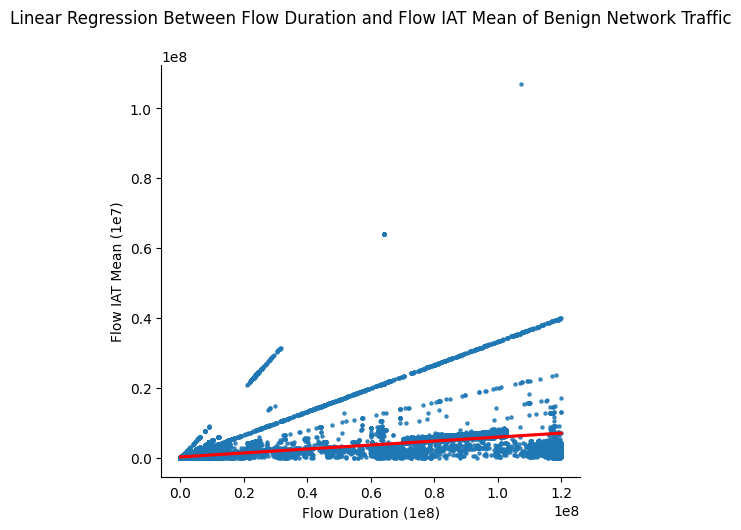

In [72]:
regress_plot = sns.lmplot(
    data=benign,
    x='Flow Duration',
    y='Flow IAT Mean',
    height=5,
    ci=95,
    scatter_kws={'s':5},
    line_kws={'color': 'red'}
)

plt.title("Linear Regression Between Flow Duration and Flow IAT Mean of Benign Network Traffic", pad=0.5, y=1.1)
plt.ylabel("Flow IAT Mean (1e7)")
plt.xlabel("Flow Duration (1e8)")
regress_plot

The Flow IAT Mean seems to increase as the Flow Duration increases.

### Q5. Create a relplot that shows multiple features in a single plot.
Select two features from your dataset and plot a scatter plot. Select two additional features you want to highlight in your data points using `hue` and `size`. Include a meaningful title to the plot.

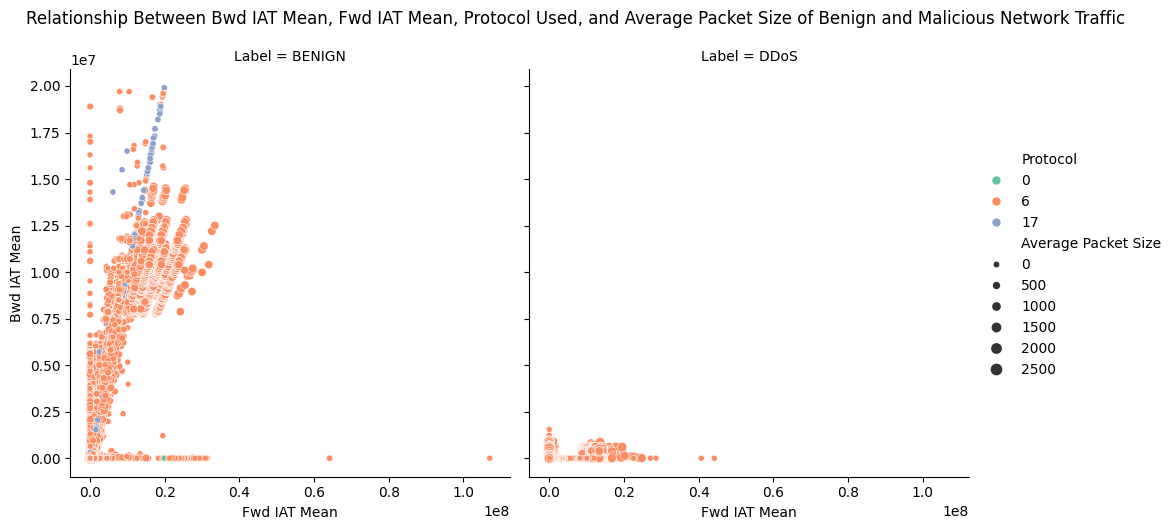

In [73]:
rel_plot = sns.relplot(
    data=ddos[ddos['Bwd IAT Mean'] < 20000000],
    x='Fwd IAT Mean',
    y='Bwd IAT Mean',
    hue='Protocol',
    size='Average Packet Size',
    col='Label',
    palette='Set2'
)

rel_plot.fig.suptitle("Relationship Between Bwd IAT Mean, Fwd IAT Mean, Protocol Used, and Average Packet Size of Benign and Malicious Network Traffic",
               y=1.05,
               x=0.5,
               ha='center')

rel_plot

The average packet size of malicious network traffric seem to be larger than benign traffic. It also looks like all malicious network traffic have faster forward and backward packet IAT Means.

### Q6: Create a plot with small multiples plots
Select two features from your dataset and show the relationship between the features with an additional feature as the single category. Organize the multiple plots to have 3 plots per row. Set the `height` of the plot to 5 and the size the of data point to 20. Include a meaningful title in the plot.

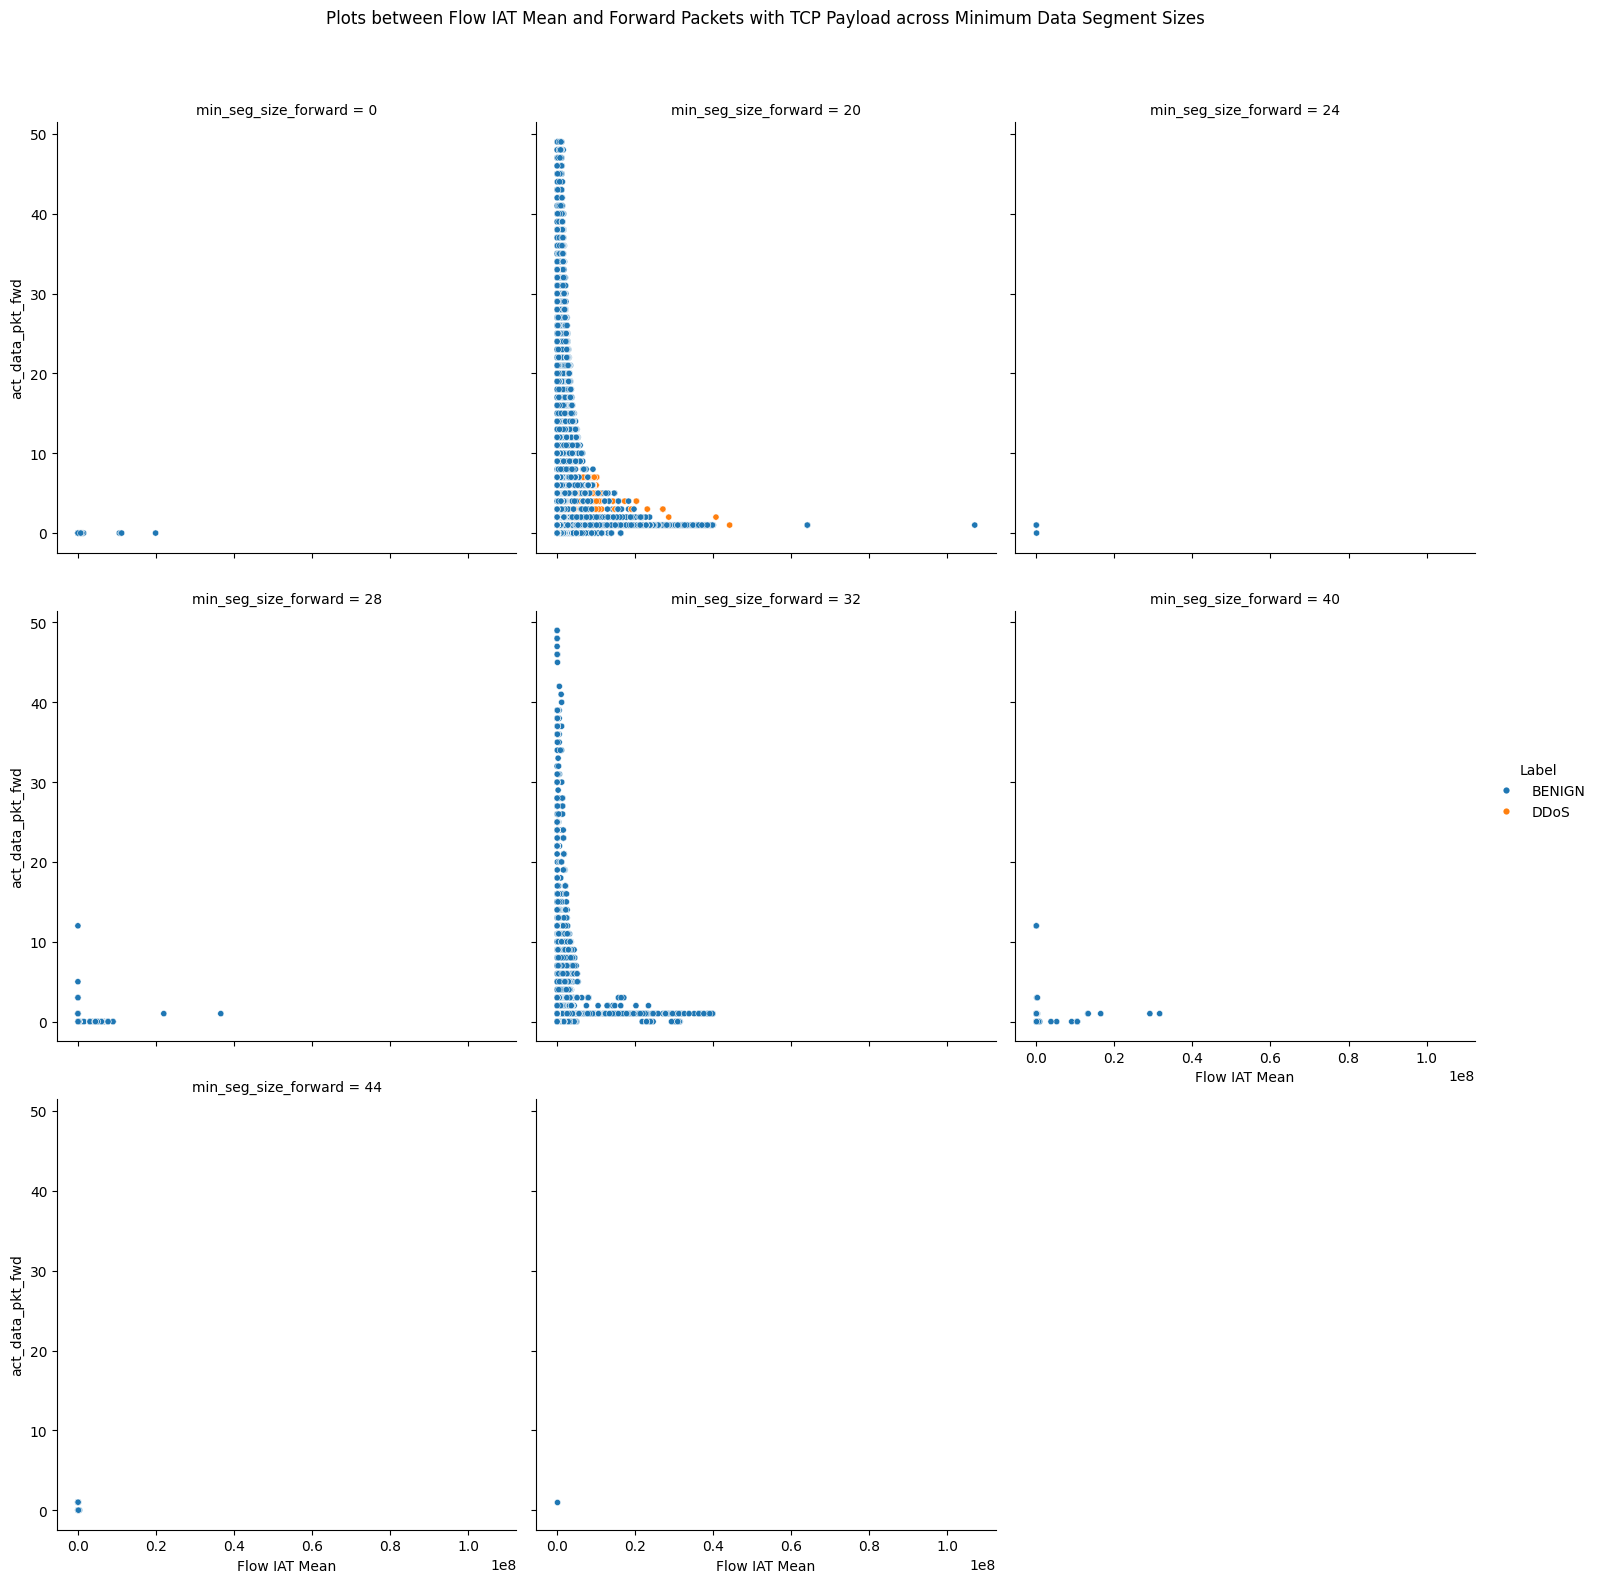

In [74]:
'''
min_seg_size_fwd Definition: It is the minimum size of the data segment in the forward direction (source to destination).
                 Context: It is used in network security, intrusion detection,
                          and flow analysis to identify potential malicious activity or specific application behaviors.

act_data_pkt_fwd Definition: a network traffic feature that represents the number of packets in the forward direction
                             containing at least 1 byte of TCP data payload

'''


multiple_plot = sns.relplot(
    data=ddos[ddos['act_data_pkt_fwd'] < 50],
    x='Flow IAT Mean',
    y='act_data_pkt_fwd',
    kind='scatter',
    hue='Label',
    col='min_seg_size_forward',
    col_wrap=3,
    height=5,
    s=20
)

plt.title("Plots between Flow IAT Mean and Forward Packets with TCP Payload across Minimum Data Segment Sizes",
          pad=0.5,
          y=3.5)

multiple_plot

All the malicious network traffic seem to have a minimum data segment size of 20, but have low number of packets that have at least 1 byte of TCP payload. All traffic looks to have a flow IAT mean on the lower end, despite being benign or malicious.